In [93]:
import torch
import numpy as np

from dinosaw.helpers import add_custom_font, get_models, ModelTypes, get_features
from dinosaw.utils import do_2D_pca

from os import listdir
from PIL import Image
from PIL.ImageColor import getcolor

from skimage.transform import resize
from skimage.color import label2rgb

from interactive_seg_backend import TrainingConfig, FeatureConfig, featurise, concat_feats, train_and_apply
from interactive_seg_backend.file_handling import load_labels

# from typing import TypeAlias, Literal

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False

In [94]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'alibi_dv2_coco')
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

f_cfg = FeatureConfig()
tr_cfg = TrainingConfig(feature_config=f_cfg, CRF=False, classifier='xgb', CRF_params={"label_confidence": 0.6,
    "sxy_g": [3, 3],
    "sxy_b": [80, 80],
    "s_rgb": [13, 13, 13],
    "compat_g": 10,
    "compat_b": 10,
    "n_infer": 10}, classifier_params={"class_weight": "balanced", "max_depth": 8}) 

In [95]:
sofc_img = Image.open("data/summary/default_image.jpg").convert('RGB')
w, h = sofc_img.size

# sofc_feats = get_features(models['dv2'], sofc_img, device=DEVICE)
# sofc_feats_red = do_2D_pca(sofc_feats, 9, post_norm='minmax')
# sofc_feats_red = sofc_feats.transpose((1, 2, 0))

In [96]:
sofc_feats: dict[ModelTypes, np.ndarray] = {}
for model in enabled_models:
    feats = get_features(models[model], sofc_img, device=DEVICE)
    feats_red = do_2D_pca(feats, 9, post_norm='minmax')
    feats_red_hr = resize(feats_red, (h, w), order=1)
    sofc_feats[model] = feats_red_hr

In [97]:
preds: dict[ModelTypes, np.ndarray] = {}

for model in enabled_models:
    feats = sofc_feats[model]
    labels = load_labels("data/summary/labels.tiff")[0]
    
    pred, _, _ = train_and_apply(feats, labels, tr_cfg, image=np.array(sofc_img))
    preds[model] = pred

2026-02-26 10:44:15 | I | core.py                    :122 | Training XGBClassifier: (10692, 9) -> ((10692,)) 
2026-02-26 10:44:15 | I | core.py                    :137 | Applying XGBClassifier to (896, 1024, 9) features
2026-02-26 10:44:15 | I | core.py                    :122 | Training XGBClassifier: (10692, 9) -> ((10692,)) 
2026-02-26 10:44:15 | I | core.py                    :137 | Applying XGBClassifier to (896, 1024, 9) features


/home/ronan/miniconda3/envs/dv2/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:44:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [98]:
COLOURS = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000"
]
COLORS = [[v / 255.0 for v in getcolor(c, "RGB")] for c in COLOURS]

def hide_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

def apply_labels_as_overlay(labels: np.ndarray, img: Image.Image, colors: list, alpha: float=1.0) -> Image.Image:
    labels_unsqueezed = np.expand_dims(labels, -1)

    overlay = label2rgb(labels, colors=colors[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=alpha)
    out = np.where(labels_unsqueezed, overlay * 255, np.array(img)).astype(np.uint8)
    img_with_labels = Image.fromarray(out)
    return img_with_labels


<PIL.Image.Image image mode=RGB size=1024x896 at 0x7FEA473CDEB0> [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


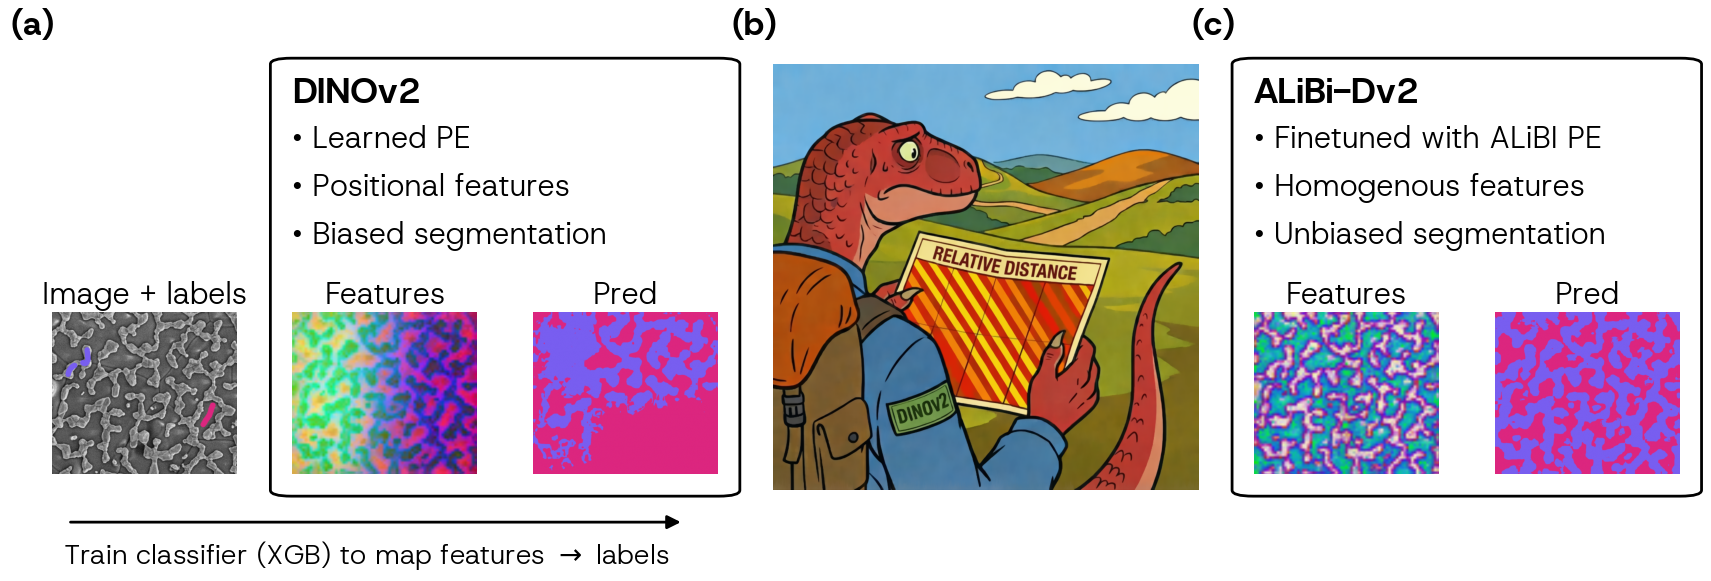

In [141]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from matplotlib.transforms import Bbox

FS = 22
add_custom_font('resources/fonts', 'Grotesk')

# ----------------------------
# Configuration
# ----------------------------

use_spacers = False           # Add spacer columns/rows
add_panel_labels = True      # Add (a), (b), (c) labels

# Width ratios for the 7 logical columns
base_widths = [1, 1, 1, 1, 1, 1, 1]  # 3 small | 2 large | 2 small

W, H = 3, 3

# Insert spacer columns (between logical blocks)
if use_spacers:
    spacer_w = 0.2
    # Insert spacer after col 2 and after col 4
    width_ratios = [
        base_widths[0],
        base_widths[1],
        base_widths[2],
        spacer_w,
        base_widths[3],
        base_widths[4],
        spacer_w,
        base_widths[5],
        base_widths[6],
    ]
else:
    width_ratios = base_widths


height_ratios = [1, 1]

# ----------------------------
# Example image data
# Replace with actual images
# ----------------------------

def random_image(seed):
    rng = np.random.default_rng(seed)
    return rng.random((200, 200, 3))

small_images = [random_image(i) for i in range(5)]
large_image = np.random.default_rng(0).random((400, 400, 3))

# ----------------------------
# Figure and GridSpec
# ----------------------------

N_ROWS = len(height_ratios)
N_COLS = len(width_ratios)

fig_w = sum([W * r for r in width_ratios])

fig = plt.figure(figsize=(W * N_COLS, H * N_ROWS))
gs = gridspec.GridSpec(
    nrows=N_ROWS,
    ncols=N_COLS,
    width_ratios=width_ratios,
    height_ratios=height_ratios,
    figure=fig,
    wspace=0.3,
    hspace=0.0
)

# Helper to map logical column index -> actual index with spacers
def col_idx(logical_idx):
    if not use_spacers:
        return logical_idx
    # spacer after col 2 and col 4
    if logical_idx <= 2:
        return logical_idx
    elif logical_idx <= 4:
        return logical_idx + 1
    else:
        return logical_idx + 2

# Logical row indices

row_top = 0
row_bottom = 1

# ----------------------------
# Small images (bottom row)
# ----------------------------

axes_small = []

# LHS small images (cols 0,1,2)
for i in range(3):
    ax = fig.add_subplot(gs[row_bottom, col_idx(i)])
    # ax.imshow(small_images[i])
    ax.set_axis_off()
    axes_small.append(ax)

# RHS small images (cols 5,6)
for i, logical_col in enumerate([5, 6]):
    ax = fig.add_subplot(gs[row_bottom, col_idx(logical_col)])
    # ax.imshow(small_images[3 + i])
    ax.set_axis_off()
    axes_small.append(ax)

print(sofc_img, labels)
# sofc_with_labels = apply_labels_as_overlay(labels, sofc_img, COLORS, alpha=1)
sofc_img_ax = axes_small[0]
sofc_img_ax.imshow(sofc_with_labels)
sofc_img_ax.set_title("Image + labels", fontsize=FS)

dv2_feat_ax = axes_small[1]
dv2_feat_ax.imshow(sofc_feats['dv2'][:, :, :3])
dv2_feat_ax.set_title("Features", fontsize=FS)

dv2_pred_ax = axes_small[2]
dv2_pred = label2rgb(preds['dv2'] + 1, colors=COLORS[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=1)
dv2_pred_ax.imshow(dv2_pred)
dv2_pred_ax.set_title("Pred", fontsize=FS)


alibi_feat_ax = axes_small[3]
alibi_feat_ax.imshow(sofc_feats['alibi_dv2_coco'][:, :, :3])
alibi_feat_ax.set_title("Features", fontsize=FS)

alibi_pred_ax = axes_small[4]
alibi_pred = label2rgb(preds['alibi_dv2_coco'] + 1, colors=COLORS[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=1)
alibi_pred_ax.imshow(alibi_pred)
alibi_pred_ax.set_title("Pred", fontsize=FS)

# ----------------------------
# Large image (spans two rows, two columns)
# ----------------------------

large_ax = fig.add_subplot(
    gs[row_top:row_bottom + 1, col_idx(3):col_idx(5)]
)
cartoon_img = Image.open("data/summary/cartoon.png").convert('RGB')
large_ax.imshow(cartoon_img)
large_ax.set_axis_off()

# ----------------------------
# Utility: Draw spanning box
# ----------------------------

def draw_group_box(fig, axes_list, title, bullets, pad=0.01):
    # Get union of axes positions in figure coordinates
    bboxes = [ax.get_position() for ax in axes_list]
    union = Bbox.union(bboxes)

    x0, y0 = union.x0, union.y0
    width, height = union.width, union.height

    # Expand vertically to match large graphic height
    large_bbox = large_ax.get_position()
    y0 = large_bbox.y0
    height = large_bbox.height

    rect = patches.FancyBboxPatch(
        (x0 - pad, y0 - pad),
        width + 2 * pad,
        height + 2 * pad,
        boxstyle="round,pad=0.01,rounding_size=0.01",
        transform=fig.transFigure,
        fill=False,
        linewidth=2
    )
    fig.add_artist(rect)

    # Add title and bullet text
    text_x = x0
    text_y = y0 + height - 0.02

    fig.text(
        text_x,
        text_y,
        title,
        fontsize=FS + 4,
        fontweight='bold',
        verticalalignment='top'
    )

    for i, bullet in enumerate(bullets):
        fig.text(
            text_x,
            text_y - 0.08 * (i + 1),
            f"• {bullet}",
            fontsize=FS,
            verticalalignment='top'
        )

# ----------------------------
# Draw LHS and RHS boxes
# ----------------------------

# LHS box: only images 2 and 3 (logical cols 1 and 2)
lhs_axes = axes_small[1:3]
draw_group_box(
    fig,
    lhs_axes,
    title="DINOv2",
    bullets=["Learned PE", "Positional features", "Biased segmentation"],
    pad=0.0005
)

# RHS box: both RHS images
rhs_axes = axes_small[3:5]
draw_group_box(
    fig,
    rhs_axes,
    title="ALiBi-Dv2",
    bullets=["Finetuned with ALiBI PE", "Homogenous features", "Unbiased segmentation"],
    pad=0.0005
)

# ----------------------------
# Optional panel labels
# ----------------------------

cartoon_bbox = large_ax.get_position()
if add_panel_labels:
    panels = [
        axes_small[0],   # first small (outside box)
        large_ax,        # large graphic
        axes_small[3],   # first RHS small
    ]
    subfig_labels = ["(a)", "(b)", "(c)"]

    for ax, lab in zip(panels, subfig_labels):
        bbox = ax.get_position()
        x = bbox.x0-0.03 if lab =="(c)" else bbox.x0 - 0.02
        fig.text(
            x,
            cartoon_bbox.y1 + 0.05,
            lab,
            fontsize=FS + 2,
            fontweight=700
        )


ARROW_X = 1.1
ARROW_Y  = -0.3
sofc_img_ax.annotate(
    '', 
    xy=(0.1, ARROW_Y), 
    xycoords='axes fraction', 
    xytext=(3.4, ARROW_Y), 
    arrowprops=dict(
        arrowstyle="<|-",  # larger arrowhead
        color='black', 
        linewidth=2,
        shrinkA=0, 
        shrinkB=0,
        mutation_scale=20  # increase arrowhead size
    )
)
sofc_img_ax.text(ARROW_X + 0.6, ARROW_Y - 0.2, r'Train classifier (XGB) to map features $\rightarrow$ labels', transform=sofc_img_ax.transAxes,
            fontsize=FS - 2, rotation=0, va='center', ha='center')




plt.show()